# **Earthquake Resilience with low complexity building**

This Jupyter Notebook demonstrates the functions of the **Assessment of Earthquake Resilience** module with the example of a low complexity, three-storey building.

The module implements linear and non-linear computations and visualizations for analyzing the earthquake resilience of a given building.

### Imports

In [ ]:
import bimquake
import pandas as pd

import warnings
warnings.filterwarnings("ignore")

### Data inputs

The following user inputs are needed for the calculations:
- latitude and longitude of the building (in decimal degrees)
- soil category - ranges from hard rock (`A`) to very soft or problematic soils (`E`)
- nominal life - the intended design service life of the structure (in years)
- topographic category - the influence of terrain features (such as hills and ridges) on wind or seismic effects. Ranges from `T1` (no inpact, flat terrain) to `T4` (upper half of a ridge, maximum amplification)
- importance class - the criticality of a structure, influences the level of seismic safety required
    - Class `I`: Low importance (e. g., agricultural or temporary building)
    - Class `II`: Ordinary structure (standard residential, commercial or office building)
    - Class `III`: Building with high occupancy or social importance (e.g., school, assembly hall)
    - Class `IV`: Essential facility and structure of vital importance for civil protection, which must remain operational after an earthquake (e.g., hospital, emergency center)
- `.xls` or `.xlsx` file with wall properties of the building in a predefined [format](https://buildchain.ilab.sztaki.hu/templates)

In [2]:
excel_file = pd.ExcelFile('small_building.xlsx')
S = bimquake.create_equivalent_frame_model_from_excel(excel_file)

### Coordinate check

In [3]:
latitude = 43.7874
longitude = 11.2499

In [4]:
ParaTR, city, country = bimquake.get_Parameters(latitude, longitude)
print("{}, {}".format(city, country))

Loading formatted geocoded file...
Florence, IT


In [5]:
f = bimquake.get_map(latitude, longitude, city, country)
f

In [6]:
ParaTR

,Return Period,ag,Fo,Tc*
0,30.0,0.047018,2.551014,0.252808
1,50.0,0.056464,2.586081,0.267521
2,72.0,0.064100,2.593636,0.276378
3,101.0,0.072345,2.590411,0.281871
4,140.0,0.080685,2.597692,0.287275
5,201.0,0.093504,2.531818,0.293817
6,475.0,0.131090,2.420610,0.301819
7,975.0,0.167652,2.390029,0.310319
8,2475.0,0.221719,2.411010,0.318801


### Settings

In [7]:
soil_category = 'A'
nominal_life = 50
topographic_category = 'T1'
importance_class = 'I'

In [8]:
S.set_location(latitude, longitude)
S.set_seismic_loading(ParaTR)
S.set_seismic_design_parameters(soil_category, nominal_life, topographic_category, importance_class)

servicee life: 50
importance class: I
class: I


### 2D layout

In [9]:
floor_id = 0
S.plot_floor_layout(floor_id)

### Linear analysis calculation

In [10]:
q = 1.5
q_ort = 3

Sfs = S.run_linear_static_analysis(q, q_ort)

In [11]:
chosen_floor = 0
Sfs[chosen_floor]

,Wall_ID,SF_VX,SF_MX,SF_MOX,SF_VY,SF_MY,SF_MOY
0,1,1.261883,1.041224,1.650558,NaN,NaN,NaN
1,2,1.345860,2.035330,1.759869,NaN,NaN,NaN
2,3,1.414672,2.975409,1.840643,NaN,NaN,NaN
3,4,1.475391,2.029866,1.906823,NaN,NaN,NaN
4,5,1.071769,1.790992,1.113372,NaN,NaN,NaN
...,...,...,...,...,...,...,...
62,63,NaN,NaN,NaN,1.313331,0.903718,1.432584
63,64,2.136764,7.503763,0.566431,NaN,NaN,NaN
64,65,1.576402,6.102255,0.460636,NaN,NaN,NaN
65,66,NaN,NaN,NaN,1.082976,1.677801,1.131774


In [12]:
direction = 'Y' # or 'X'
floor_id = 0
safety_factor_type = 'Shear' # or 'Bending in plane' or 'Bending out of plane'

S.plot_wall_safety_factors(Sfs, direction, floor_id, safety_factor_type)

### Pushover analysis calculation

In [13]:
method = 'Ductility' # or 'Drift'
algorithm = 'incr' # or 'add' (Incremental or Additive)
mu = 1.5

In [14]:
k_ult_TOT, Hult_TOT, vr_ult_TOT, L_organized = S.get_force_displacement_capacity_curve(method, algorithm, mu)
v_bl, H_bl = S.get_bilinear_capacity_curve_coords(vr_ult_TOT, Hult_TOT)
pushover_results = S.assess_seismic_performance_get_ADRS_params(k_ult_TOT, Hult_TOT, vr_ult_TOT, H_bl, v_bl)

### Outputs

In [15]:
df2 = S.get_global_vulnerability_metrics(v_bl, pushover_results)
df2

,Direction,Safety Index,PGA_C,TR,δ,d* (t)
0,X,1.28,0.15,659.0,16.67,16.13
1,Y,1.29,0.15,668.0,17.28,15.21


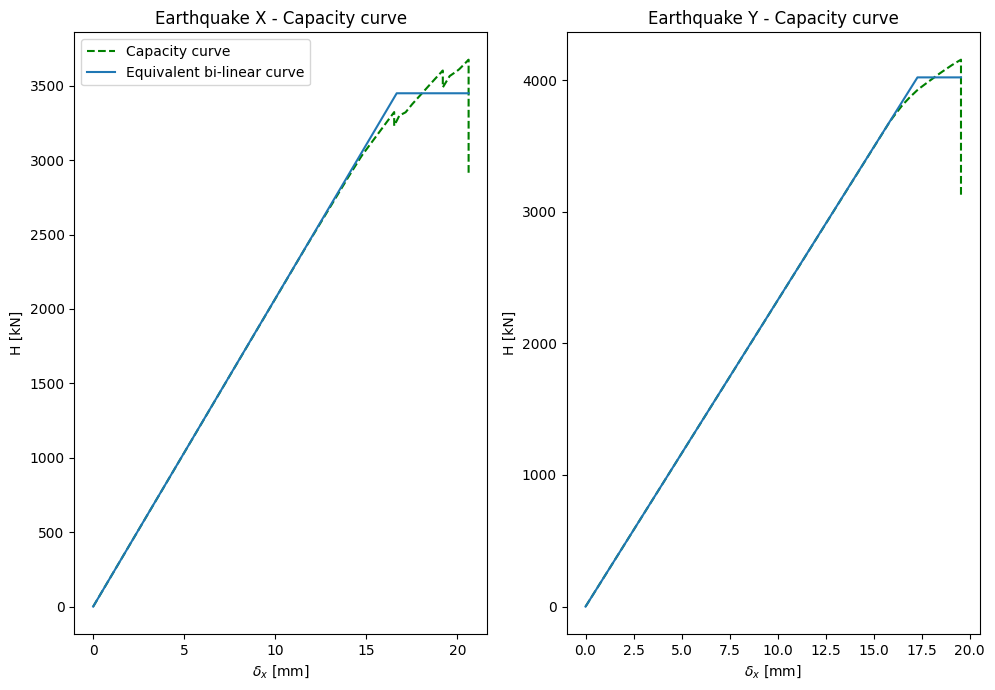

In [16]:
fig1 = S.plot_capacity_curve(vr_ult_TOT, Hult_TOT, v_bl, H_bl)

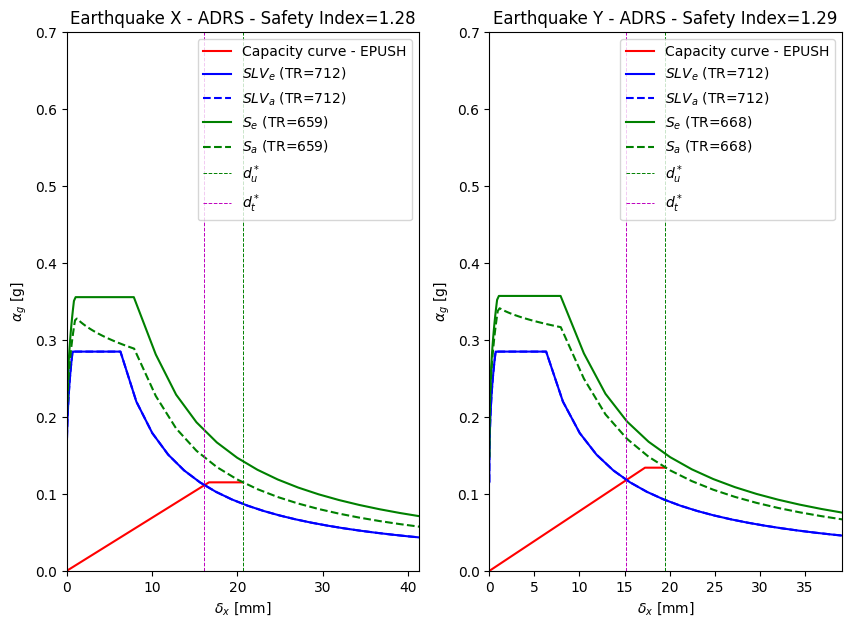

In [17]:
fig2 = S.plot_ADRS_demand_and_capacity(v_bl, pushover_results)

In [18]:
direction = 'X' # or 'Y'
floor_id = 0

S.plot_failing_walls(L_organized, 'X', floor_id)